# 05 · PJM Energy Demand — Multivariate: Regional Panel, PCA Common Factor, Lead-Lag

## Part 5 — Multivariate Analysis: The Regional Panel

So far, one zone (PJME). PJM actually reports many regional zones, and the natural question is **how
together do they move?** We take the six zones with full overlapping history (2005–2018) and ask:
how correlated are they, is there a single **common factor**, and does any region **lead** another (a
forecasting edge)? The answer is a textbook illustration of a system driven by one shared force —
**weather** — across a whole continent-scale grid.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 130, "display.max_columns", 40)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
po = data.panel_overlap()
print("overlap panel:", po.shape, "| zones:", list(po.columns), "|", po.index.min().date(), "->", po.index.max().date())

setup ok | numpy 2.1.3 | pandas 2.3.3


overlap panel: (116183, 6) | zones: ['PJME', 'PJMW', 'AEP', 'DAYTON', 'DOM', 'DUQ'] | 2005-05-01 -> 2018-08-03


### 1. How correlated are the zones?

Every pair of zones correlates **0.83–0.94** — extraordinarily tight for separate geographic regions.
They rise and fall almost in lockstep, because the same heat waves and cold snaps sweep the whole
interconnection at once.

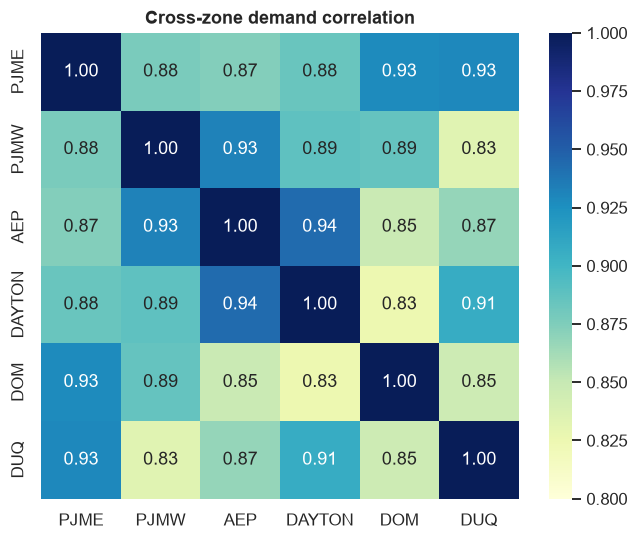

mean off-diagonal correlation: 0.88


In [2]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(po.corr(), annot=True, fmt=".2f", cmap="YlGnBu", vmin=.8, vmax=1, ax=ax)
ax.set_title("Cross-zone demand correlation")
eda.savefig(fig, "p5_corr.png"); plt.show()
print("mean off-diagonal correlation: %.2f" % po.corr().values[np.triu_indices(len(po.columns),1)].mean())

### 2. PCA — one factor runs the grid

Standardise and decompose. **The first principal component explains ~90% of all variance**, with
**equal loadings** on every zone — i.e. PC1 is essentially *total system demand*. It correlates **0.99**
with the simple sum of the zones. One latent, weather-driven signal moves the entire grid up and down;
the regions are near-copies scaled to size.

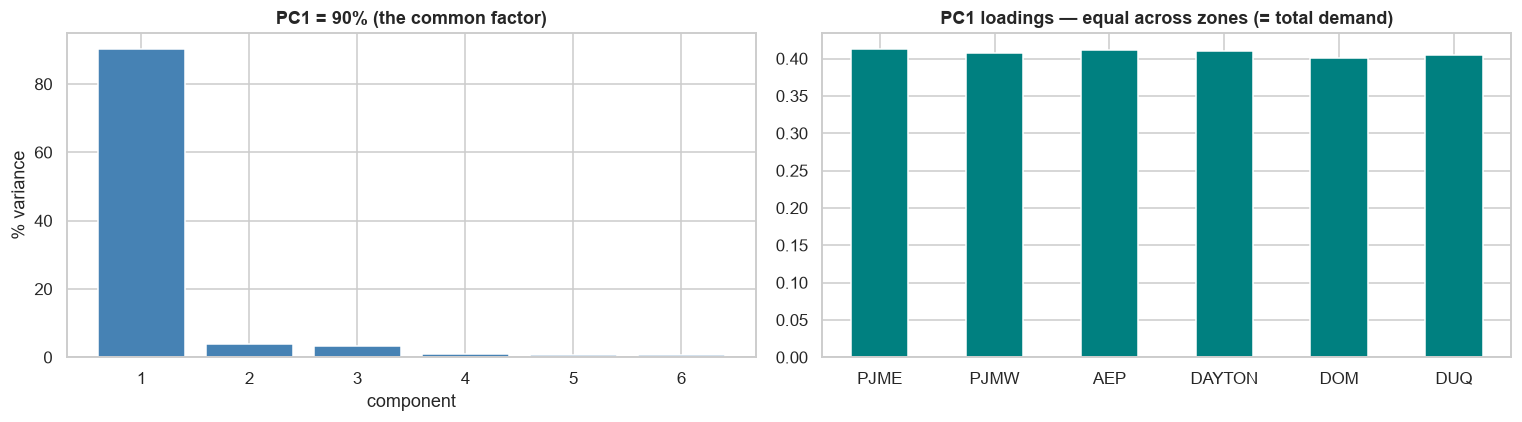

PC1 90.4% | PC2 3.8% | corr(PC1, total demand) = 0.992


In [3]:
X = StandardScaler().fit_transform(po)
pca = PCA().fit(X); evr = pca.explained_variance_ratio_
pc1 = pca.transform(X)[:, 0]; total = po.sum(1).values
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(range(1, len(evr)+1), evr*100, color="steelblue"); ax[0].set_xlabel("component"); ax[0].set_ylabel("% variance"); ax[0].set_title(f"PC1 = {evr[0]*100:.0f}% (the common factor)")
pd.Series(pca.components_[0], index=po.columns).plot.bar(ax=ax[1], color="teal", rot=0); ax[1].set_title("PC1 loadings — equal across zones (= total demand)")
fig.tight_layout(); eda.savefig(fig, "p5_pca.png"); plt.show()
print("PC1 %.1f%% | PC2 %.1f%% | corr(PC1, total demand) = %.3f" % (evr[0]*100, evr[1]*100, abs(np.corrcoef(pc1, total)[0,1])))

### 3. What the *other* components capture

If PC1 is the shared level, PC2/PC3 are the **regional idiosyncrasies** — the ways zones differ. Their
loadings split the western zones (AEP/DAYTON) from the eastern (PJME/DOM), i.e. a small east–west
contrast riding on top of the dominant common factor. Useful to know which regions are *not*
interchangeable.

In [4]:
load = pd.DataFrame(pca.components_[:3].T, index=po.columns, columns=["PC1","PC2","PC3"])
print(load.round(2).to_string())
print("\n-> PC2/PC3 (≈%.0f%% combined) encode east-west regional differences atop the shared level." % ((evr[1]+evr[2])*100))

         PC1   PC2   PC3
PJME    0.41  0.42  0.16
PJMW    0.41 -0.21 -0.54
AEP     0.41 -0.48 -0.15
DAYTON  0.41 -0.44  0.27
DOM     0.40  0.58 -0.40
DUQ     0.41  0.14  0.65

-> PC2/PC3 (≈7% combined) encode east-west regional differences atop the shared level.


### 4. Lead–lag — do regions move *simultaneously*?

Could one zone's demand *predict* another's an hour ahead? We cross-correlate two zones at hourly
shifts. The peak sits squarely at **lag 0** — the regions move **together**, not in sequence, because
weather is the common driver and it arrives everywhere at once. So there's *no* cross-region
forecasting shortcut; each zone's own past is what helps (Part 8).

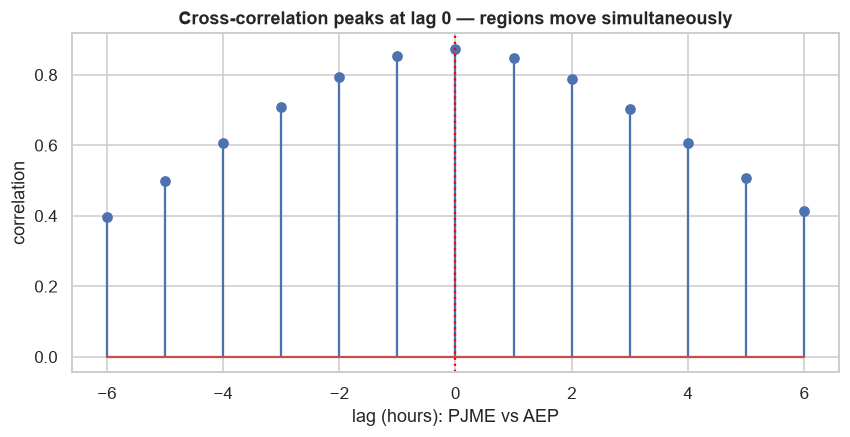

peak cross-correlation at lag 0 hours (0 = simultaneous)


In [5]:
a = (po["PJME"] - po["PJME"].mean()).values; b = (po["AEP"] - po["AEP"].mean()).values
def ccf_lag(a, b, lag):
    if lag > 0: return np.corrcoef(a[lag:], b[:-lag])[0,1]
    if lag < 0: return np.corrcoef(a[:lag], b[-lag:])[0,1]
    return np.corrcoef(a, b)[0,1]
lags = range(-6, 7); cc = [ccf_lag(a, b, l) for l in lags]
fig, ax = plt.subplots(figsize=(9, 4)); ax.stem(list(lags), cc)
ax.axvline(0, color="red", ls=":"); ax.set_xlabel("lag (hours): PJME vs AEP"); ax.set_ylabel("correlation"); ax.set_title("Cross-correlation peaks at lag 0 — regions move simultaneously")
eda.savefig(fig, "p5_leadlag.png"); plt.show()
print("peak cross-correlation at lag %d hours (0 = simultaneous)" % list(lags)[int(np.argmax(cc))])

### Takeaways

- The six zones are **extremely correlated** (0.83–0.94) — a continent-scale grid breathing in unison.
- **PCA finds one dominant factor (~90%)** with equal loadings = *total system demand*, weather-driven
  (corr 0.99 with the sum). PC2/PC3 are small **east–west** regional contrasts.
- **No lead–lag**: zones move **simultaneously** (cross-correlation peaks at lag 0) — weather hits
  everywhere at once, so there's no cross-region forecasting edge.
- Practical upshot: model the **aggregate** (or each zone from its *own* history); the regions carry
  little independent information.

**Next — Part 6 (Anomaly & event detection):** find the unusual hours and days — holidays, heat-wave
peaks, and structural breaks — using STL-residual scoring and change-point detection.